Libraries imported and styles set.
Loading enhanced dataset from: ../../data/processed/enhanced_features_dataset.csv
Loaded enhanced dataset: 2000 rows, 90 columns
Loading stable features from: ../../src/models/stable_features.txt
Loaded 7 stable features

Attack type distribution:
attack_type
Normal             1999
Brute Force-Web       1
Name: count, dtype: int64

Binary class distribution:
is_attack
False    1999
True        1
Name: count, dtype: int64


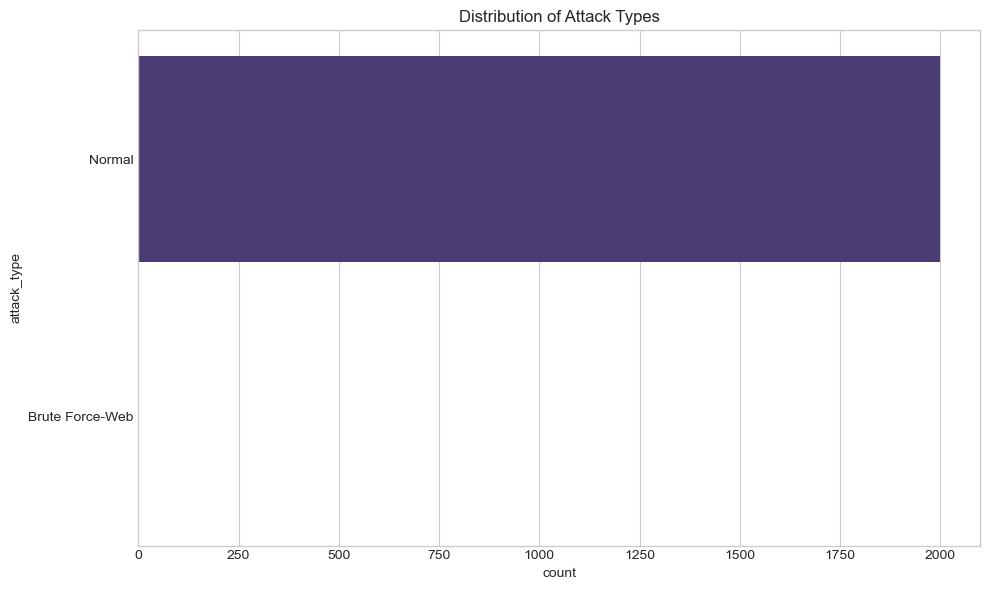


Testing undersampling with ratio 1.0:1
Original dataset: 1999 normal samples, 1 attack samples
Undersampling: Created dataset with 1 normal samples (ratio 1.0:1)
Using 7 features for training
Error during training/evaluation: The least populated class in y has only 1 member, which is too few. The minimum number of groups for any class cannot be less than 2.

Testing undersampling with ratio 2.0:1
Original dataset: 1999 normal samples, 1 attack samples
Undersampling: Created dataset with 2 normal samples (ratio 2.0:1)
Using 7 features for training
Error during training/evaluation: The least populated class in y has only 1 member, which is too few. The minimum number of groups for any class cannot be less than 2.

Testing undersampling with ratio 5.0:1
Original dataset: 1999 normal samples, 1 attack samples
Undersampling: Created dataset with 5 normal samples (ratio 5.0:1)
Using 7 features for training
Error during training/evaluation: The least populated class in y has only 1 member, w

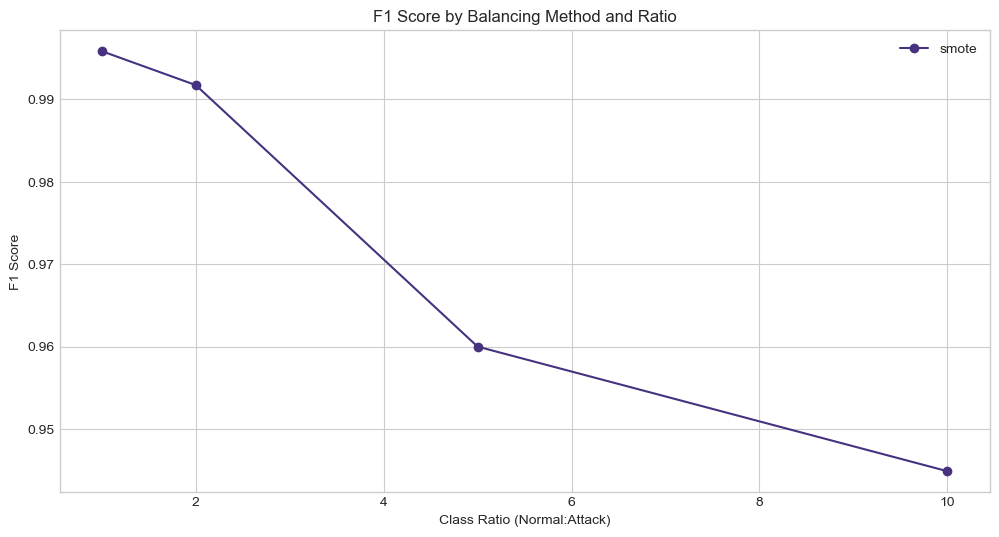


Top balancing approaches by F1 score:
  method  ratio  precision  recall        f1  threshold class_weight
0  smote    1.0   0.991736     1.0  0.995851  -0.095761         None
1  smote    2.0   0.983607     1.0  0.991736  -0.114142         None
2  smote    5.0   0.923077     1.0  0.960000  -0.092172         None
3  smote   10.0   0.895522     1.0  0.944882  -0.096715         None

Best balancing approach saved to src/models/best_balancing.json
Best approach: smote with ratio 1.0


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib
import json
from sklearn.model_selection import train_test_split
from sklearn.ensemble import IsolationForest
from sklearn.metrics import precision_recall_fscore_support, roc_auc_score
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# Set plot styles
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')
print("Libraries imported and styles set.")

# Load enhanced dataset and stable features
def load_data_and_features():
    """Load the enhanced dataset and stable features"""
    dataset_path = '../../data/processed/enhanced_features_dataset.csv'
    features_path = '../../src/models/stable_features.txt'
    
    if os.path.exists(dataset_path):
        print(f"Loading enhanced dataset from: {dataset_path}")
        try:
            df = pd.read_csv(dataset_path)
            print(f"Loaded enhanced dataset: {df.shape[0]} rows, {df.shape[1]} columns")
        except Exception as e:
            print(f"Error loading enhanced dataset: {e}")
            return None, []
    else:
        print(f"Enhanced dataset not found at {dataset_path}")
        return None, []
    
    if os.path.exists(features_path):
        print(f"Loading stable features from: {features_path}")
        try:
            with open(features_path, 'r') as f:
                features = [line.strip() for line in f if line.strip()]
            print(f"Loaded {len(features)} stable features")
        except Exception as e:
            print(f"Error loading stable features: {e}")
            return df, []
    else:
        print(f"Stable features file not found at {features_path}")
        return df, []
    
    return df, features

# Load data
df, stable_features = load_data_and_features()

# Display attack distribution
if df is not None and 'attack_type' in df.columns:
    print("\nAttack type distribution:")
    attack_counts = df['attack_type'].value_counts()
    print(attack_counts)
    
    # Create binary target
    df['is_attack'] = df['attack_type'] != 'Normal'
    print(f"\nBinary class distribution:")
    print(df['is_attack'].value_counts())
    
    # Plot attack distribution
    plt.figure(figsize=(10, 6))
    sns.countplot(y='attack_type', data=df, order=df['attack_type'].value_counts().index)
    plt.title('Distribution of Attack Types')
    plt.tight_layout()
    plt.show()
else:
    print("Cannot display attack distribution. DataFrame or 'attack_type' column not available.")

# Function to create differently balanced datasets
def create_balanced_dataset(df, method='undersampling', ratio=1.0):
    """Create a balanced dataset using different methods"""
    if df is None:
        print("DataFrame is None. Cannot create balanced dataset.")
        return None, None
        
    if 'is_attack' not in df.columns:
        print("No 'is_attack' column found. Creating it from attack_type.")
        df['is_attack'] = df['attack_type'] != 'Normal'
    
    normal_df = df[df['is_attack'] == False]
    attack_df = df[df['is_attack'] == True]
    
    n_attacks = len(attack_df)
    n_normal = len(normal_df)
    
    print(f"Original dataset: {n_normal} normal samples, {n_attacks} attack samples")
    
    if n_attacks == 0:
        print("Warning: No attack samples found in dataset.")
        return df, None  # Return original dataset
    
    if method == 'undersampling':
        # Undersampling majority class
        n_normal_sampled = int(n_attacks * ratio)
        n_normal_sampled = min(n_normal_sampled, n_normal)  # Ensure we don't request more than available
        
        normal_sampled = normal_df.sample(n=n_normal_sampled, random_state=42)
        balanced_df = pd.concat([normal_sampled, attack_df])
        
        print(f"Undersampling: Created dataset with {n_normal_sampled} normal samples (ratio {ratio}:1)")
        
        class_weight = None  # No class weight for undersampling
        
    elif method == 'smote':
        # Check if we have enough attack samples for SMOTE
        if n_attacks < 5:
            print(f"Warning: Only {n_attacks} attack samples found. SMOTE requires at least 5 samples.")
            print("Falling back to simple oversampling.")
            
            # Simple oversampling with replacement
            attack_oversampled = attack_df.sample(n=int(n_normal/ratio), replace=True, random_state=42)
            balanced_df = pd.concat([normal_df, attack_oversampled])
            
            print(f"Simple oversampling: Created dataset with {len(attack_oversampled)} attack samples")
            
        else:
            # Use SMOTE for synthetic samples
            # First select only numeric features
            numeric_features = df.select_dtypes(include=np.number).columns.tolist()
            numeric_features = [f for f in numeric_features if f != 'is_attack']
            
            # Feature columns must be included in the DataFrame
            available_features = [f for f in numeric_features if f in df.columns]
            
            X = df[available_features]
            y = df['is_attack']
            
            # Calculate appropriate ratio
            sampling_strategy = min(1.0, ratio * n_normal / n_attacks)
            
            try:
                smote = SMOTE(sampling_strategy=sampling_strategy, random_state=42)
                X_resampled, y_resampled = smote.fit_resample(X, y)
                
                # Recreate dataframe
                balanced_df = pd.DataFrame(X_resampled, columns=available_features)
                balanced_df['is_attack'] = y_resampled
                
                # Add back non-numeric columns
                # For attack samples, get from attack_df
                # For normal samples, get from normal_df
                non_numeric = [col for col in df.columns if col not in available_features and col != 'is_attack']
                
                # Since SMOTE creates synthetic samples, we can't directly map back non-numeric features
                # We'll use a simplified approach: assign a default value
                for col in non_numeric:
                    if col == 'attack_type':
                        # For attack_type, use the label based on is_attack
                        balanced_df['attack_type'] = balanced_df['is_attack'].map({False: 'Normal', True: 'Synthetic'})
                    else:
                        # For other columns, use the most common value from the original dataset
                        balanced_df[col] = df[col].mode()[0]
                
                print(f"SMOTE: Created dataset with {sum(y_resampled)} attack samples and {len(y_resampled) - sum(y_resampled)} normal samples")
                
            except Exception as e:
                print(f"Error applying SMOTE: {e}")
                print("Falling back to simple oversampling.")
                
                # Simple oversampling with replacement
                attack_oversampled = attack_df.sample(n=int(n_normal/ratio), replace=True, random_state=42)
                balanced_df = pd.concat([normal_df, attack_oversampled])
                
                print(f"Simple oversampling: Created dataset with {len(attack_oversampled)} attack samples")
        
        class_weight = None  # No class weight for SMOTE
        
    elif method == 'weighted':
        # Return original dataset with class weights
        balanced_df = df.copy()
        
        # Calculate class weights
        class_weight = {
            False: 1,
            True: ratio * n_normal / n_attacks
        }
        
        print(f"Weighted: Using original dataset with class weights: {class_weight}")
        
    else:
        print(f"Unknown balancing method: {method}. Using original dataset.")
        balanced_df = df.copy()
        class_weight = None
    
    return balanced_df, class_weight

# Test different balancing approaches
if df is not None:
    methods = ['undersampling', 'smote', 'weighted']
    ratios = [1.0, 2.0, 5.0, 10.0]
    
    results = []
    
    for method in methods:
        for ratio in ratios:
            print(f"\nTesting {method} with ratio {ratio}:1")
            
            # Create balanced dataset
            balanced_df, class_weight = create_balanced_dataset(df, method=method, ratio=ratio)
            
            if balanced_df is None:
                print(f"Could not create balanced dataset with {method} and ratio {ratio}")
                continue
            
            # Check if we have features
            if not stable_features:
                print("No stable features available. Using all numeric features.")
                feature_cols = balanced_df.select_dtypes(include=np.number).columns.tolist()
                feature_cols = [col for col in feature_cols if col not in ['is_attack']]
            else:
                feature_cols = [f for f in stable_features if f in balanced_df.columns]
            
            if len(feature_cols) == 0:
                print("No valid features available for training.")
                continue
            
            print(f"Using {len(feature_cols)} features for training")
            
            # Split data
            X = balanced_df[feature_cols]
            y = balanced_df['is_attack']
            
            try:
                X_train, X_test, y_train, y_test = train_test_split(
                    X, y, test_size=0.3, random_state=42, stratify=y
                )
                
                # Train Isolation Forest
                iforest = IsolationForest(
                    n_estimators=100,
                    contamination=0.1,  # Fixed contamination for comparability
                    random_state=42
                )
                
                # Fit on training data
                iforest.fit(X_train[y_train == False])  # Only fit on normal samples for anomaly detection
                
                # Predict on test data
                scores = iforest.decision_function(X_test)
                
                # Find optimal threshold
                thresholds = np.linspace(min(scores), max(scores), 100)
                best_f1 = 0
                best_threshold = 0
                best_precision = 0
                best_recall = 0
                
                for threshold in thresholds:
                    y_pred = (scores <= threshold).astype(int)
                    precision, recall, f1, _ = precision_recall_fscore_support(
                        y_test, y_pred, average='binary', zero_division=0
                    )
                    
                    if f1 > best_f1:
                        best_f1 = f1
                        best_threshold = threshold
                        best_precision = precision
                        best_recall = recall
                
                # Store results
                result = {
                    'method': method,
                    'ratio': ratio,
                    'precision': best_precision,
                    'recall': best_recall,
                    'f1': best_f1,
                    'threshold': best_threshold,
                    'class_weight': class_weight
                }
                
                results.append(result)
                
                print(f"Results: Precision={best_precision:.4f}, Recall={best_recall:.4f}, F1={best_f1:.4f}, Threshold={best_threshold:.4f}")
                
            except Exception as e:
                print(f"Error during training/evaluation: {e}")
    
    # Compare results
    if results:
        # Create results DataFrame
        results_df = pd.DataFrame(results)
        
        # Plot F1 scores
        plt.figure(figsize=(12, 6))
        for method in methods:
            method_results = results_df[results_df['method'] == method]
            if not method_results.empty:
                plt.plot(method_results['ratio'], method_results['f1'], marker='o', label=method)
        
        plt.xlabel('Class Ratio (Normal:Attack)')
        plt.ylabel('F1 Score')
        plt.title('F1 Score by Balancing Method and Ratio')
        plt.legend()
        plt.grid(True)
        plt.show()
        
        # Show top results
        print("\nTop balancing approaches by F1 score:")
        top_results = results_df.sort_values('f1', ascending=False).head(5)
        print(top_results)
        
        # Save best approach to file
        best_result = results_df.loc[results_df['f1'].idxmax()]
        
        try:
            os.makedirs('../../src/models', exist_ok=True)
            with open('../../src/models/best_balancing.json', 'w') as f:
                json.dump({
                    'method': best_result['method'],
                    'ratio': float(best_result['ratio']),
                    'threshold': float(best_result['threshold']),
                    'f1': float(best_result['f1']),
                    'precision': float(best_result['precision']),
                    'recall': float(best_result['recall'])
                }, f, indent=4)
            
            print(f"\nBest balancing approach saved to src/models/best_balancing.json")
            print(f"Best approach: {best_result['method']} with ratio {best_result['ratio']}")
        except Exception as e:
            print(f"Error saving best balancing approach: {e}")
    else:
        print("\nNo results to compare.")
else:
    print("Cannot test balancing approaches. DataFrame not available.")